# Recon Analysis

Compare two session files for differences

**Before running:** set `DATA_FOLDER` to the folder containing your
session output CSV files. 

In [ ]:
import pandas as pd
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

DATA_FOLDER = Path(r"C:\Git\CandleStateSessionAnalysis\data\recon")
OUTPUT_FOLDER = DATA_FOLDER / "output" 

In [ ]:
import parse_sessions

tables = parse_sessions.parse_sessions(DATA_FOLDER)

# from IPython.display import display
# for table_name, df in tables.items():
#     print(f"### {table_name}")
#     display(df.describe())

trade_signals = tables["trade_signals"]
# out_path = OUTPUT_FOLDER / f"trade_signals.csv"
# trade_signals.to_csv(out_path, index=False)

Parsed Session_Live__2026-07-10__2026-07-10_1546.json: trade_signals=750, price_levels=60, orders=8, transactions=15, positions=7, logs=3146
Parsed Session_Live__2026-07-10__2026-07-10_1607.json: trade_signals=674, price_levels=58, orders=14, transactions=10, positions=4, logs=4153


In [22]:

key_cols = ['Symbol', 'CandleOpen']
compare_cols = ['Close', 'Volume', 'VolumeRatio', 'VWAP']

pivot = trade_signals.pivot_table(
    index=key_cols,
    columns='SourceFile',
    values=compare_cols,
    aggfunc='first'
)

pivot.columns = [f'{val}__{src}' for val, src in pivot.columns]
pivot = pivot.reset_index()

sources = sorted(trade_signals['SourceFile'].unique())
s1, s2 = sources

pivot['Close_diff']  = pivot[f'Close__{s1}']  - pivot[f'Close__{s2}']
pivot['Volume_diff'] = pivot[f'Volume__{s1}'] - pivot[f'Volume__{s2}']

diffs_only = pivot[(pivot['Close_diff'] != 0) | (pivot['Volume_diff'] != 0)]
diffs_only.head(10)

,Symbol,CandleOpen,Close__Session_Live__2026-07-10__2026-07-10_1546.json,Close__Session_Live__2026-07-10__2026-07-10_1607.json,VWAP__Session_Live__2026-07-10__2026-07-10_1546.json,VWAP__Session_Live__2026-07-10__2026-07-10_1607.json,Volume__Session_Live__2026-07-10__2026-07-10_1546.json,Volume__Session_Live__2026-07-10__2026-07-10_1607.json,VolumeRatio__Session_Live__2026-07-10__2026-07-10_1546.json,VolumeRatio__Session_Live__2026-07-10__2026-07-10_1607.json,Close_diff,Volume_diff
0,QID,2026-07-10T09:30:00-04:00,14.0900,14.0900,14.102333,14.102333,201092.0,184493.0,1.462682,1.365498,0.0,16599.0
1,QID,2026-07-10T09:32:00-04:00,14.0599,14.0599,14.093801,14.092970,63157.0,65589.0,0.439548,0.462995,0.0,-2432.0
2,QID,2026-07-10T09:34:00-04:00,14.0600,14.0600,14.088887,14.087861,38702.0,39283.0,0.293609,0.302470,0.0,-581.0
3,QID,2026-07-10T09:36:00-04:00,14.0600,14.0600,14.083035,14.081920,76956.0,78432.0,0.600531,0.620425,0.0,-1476.0
4,QID,2026-07-10T09:38:00-04:00,14.0950,14.0950,14.083736,14.082802,57890.0,58668.0,0.496131,0.509873,0.0,-778.0
5,QID,2026-07-10T09:40:00-04:00,14.1350,14.1350,14.089846,14.089259,63967.0,64935.0,0.626155,0.644978,0.0,-968.0
6,QID,2026-07-10T09:42:00-04:00,14.1000,14.1000,14.091254,14.090759,37688.0,38307.0,0.489044,0.506221,0.0,-619.0
7,QID,2026-07-10T09:44:00-04:00,14.0999,14.0999,14.091903,14.091468,43392.0,44197.0,0.795658,0.794479,0.0,-805.0
8,QID,2026-07-10T09:46:00-04:00,14.0600,14.0600,14.090250,14.089975,41026.0,36933.0,0.798568,0.716639,0.0,4093.0
9,QID,2026-07-10T09:48:00-04:00,14.0299,14.0299,14.088698,14.087992,20550.0,26103.0,0.421268,0.525702,0.0,-5553.0


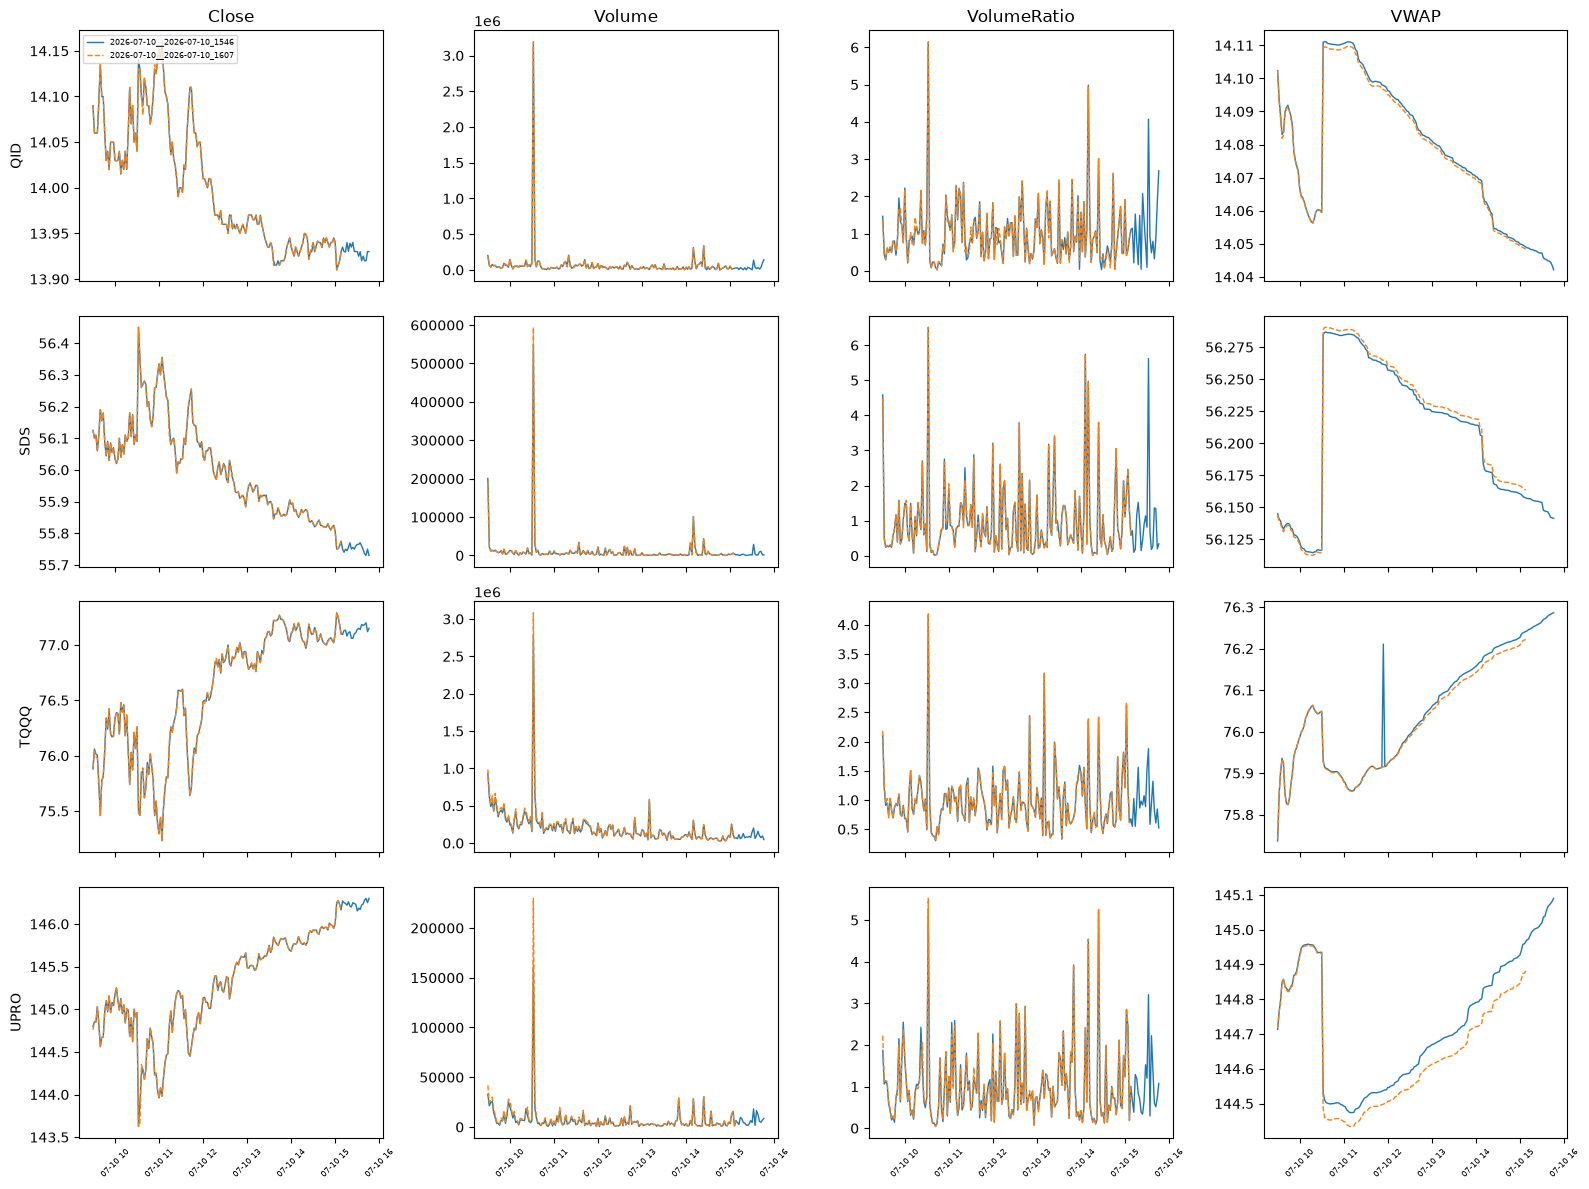

In [23]:
import matplotlib.pyplot as plt

trade_signals['CandleOpen'] = pd.to_datetime(trade_signals['CandleOpen'])

compare_cols = ['Close', 'Volume', 'VolumeRatio', 'VWAP']
symbols = sorted(trade_signals['Symbol'].unique())
sources = sorted(trade_signals['SourceFile'].unique())
s1, s2 = sources

fig, axes = plt.subplots(len(symbols), len(compare_cols),
                          figsize=(4*len(compare_cols), 3*len(symbols)),
                          sharex='col')

for i, sym in enumerate(symbols):
    sub = trade_signals[trade_signals['Symbol'] == sym]
    for j, col in enumerate(compare_cols):
        ax = axes[i, j]
        for src, style in zip([s1, s2], ['-', '--']):
            s = sub[sub['SourceFile'] == src].sort_values('CandleOpen')
            ax.plot(s['CandleOpen'], s[col], style,
                    label=src.replace('Session_Live__','').replace('.json',''),
                    linewidth=1)
        if i == 0:
            ax.set_title(col)
        if j == 0:
            ax.set_ylabel(sym)
        ax.tick_params(axis='x', rotation=45, labelsize=6)

axes[0, 0].legend(fontsize=6, loc='upper left')
plt.tight_layout()
plt.show()